In [207]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

In [208]:
#Data (We use log returns)
data = yf.download('SPY', start='2000-01-01', end='2025-01-01', auto_adjust=True)
close = data['Close'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

print(f"Data loaded: {len(returns)} trading days")
print(returns.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 6288 trading days
Date
2000-01-04   -0.039892
2000-01-05    0.001787
2000-01-06   -0.016202
2000-01-07    0.056453
2000-01-10    0.003425
Name: SPY, dtype: float64


In [209]:
# 80% train, 20% test
split = int(len(returns) * 0.8)
train_returns = returns.iloc[:split]
test_returns = returns.iloc[split:]

print(f"Train: {len(train_returns)} days")
print(f"Test: {len(test_returns)} days")

Train: 5030 days
Test: 1258 days


In [210]:
#Fit the model

#3 hidden States, full covariance, Max 200 Baum-Welch iterations, seed
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42) 

#train_returns (pandas to np array, reshape to 2D array)
model.fit(train_returns.values.reshape(-1,1))

print(f"Converged: {model.monitor_.converged}") #Returns true if success

Converged: True


In [211]:
#Predict on the full dataset (train + test)
states = model.predict(returns.values.reshape(-1,1)) #Vitebri Algorithm

# Label states by mean return (sorted ascending: lowest = Bearish, highest = Bullish)

#[states == s] produces a boolean mask, splits array into 3 according to s value
state_means = [returns.values[states == s].mean() for s in range(3)]

#argument sort, returns the indices that would store an array in ascending order
sorted_states = np.argsort(state_means)

#dictionaries
state_labels = {sorted_states[0]: 'Bearish', sorted_states[1]: 'Neutral', sorted_states[2]: 'Bullish'}
colors = {sorted_states[0]: '#d62728', sorted_states[1]: '#aec7e8', sorted_states[2]: '#2ca02c'}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Bullish': '0.0016', 'Neutral': '-0.0001', 'Bearish': '-0.0007'}


2020-01-02 00:00:00


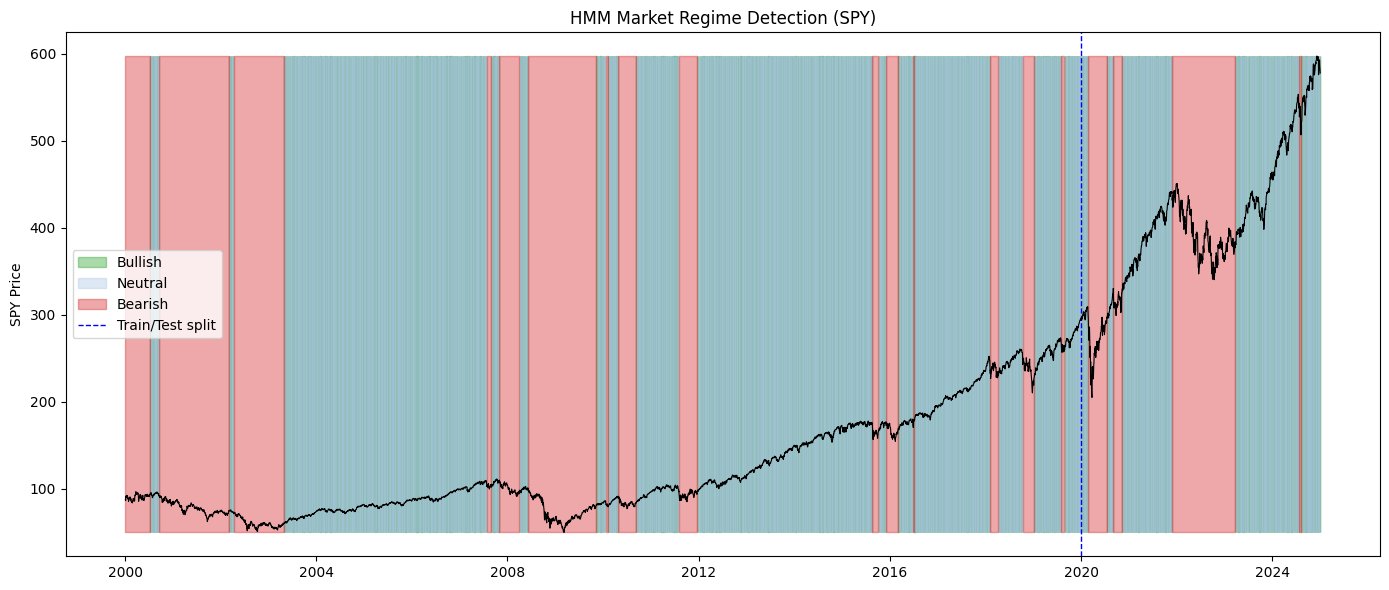

In [212]:
#Plot regimes
plt.figure(figsize=(14, 6))

# Plot price line first
plt.plot(returns.index, close.loc[returns.index], color='black', linewidth=0.8, zorder=3)

# Shade background by regime
for state in range(3):
    mask = (states == state)
    # Find contiguous blocks of the same state
    plt.fill_between(returns.index, close.loc[returns.index].min(), close.loc[returns.index].max(),
                     where=mask, alpha=0.4, color=colors[state], label=state_labels[state])

#Mark train/test split
split_date = returns.index[split]
print(split_date)

#Plot a vertical line
plt.axvline(split_date, color='blue', linestyle='--', linewidth=1, label='Train/Test split')

plt.legend()
plt.title('HMM Market Regime Detection (SPY)')
plt.ylabel('SPY Price')
plt.tight_layout()
plt.show()

In [214]:
for state in range(3):
    regime_returns = returns.values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Bullish  | Mean: 0.0016 | Std: 0.0046 | Days: 2233
Neutral  | Mean: -0.0001 | Std: 0.0089 | Days: 1891
Bearish  | Mean: -0.0007 | Std: 0.0184 | Days: 2164
